# Seller Churn Analysis — Flipkart/Amazon-style Marketplace

**Business problem:** ~40% of marketplace sellers churn (stop selling) within their first year.
This notebook identifies what drives churn, segments sellers into archetypes, builds a predictive
model to flag at-risk sellers, and quantifies the revenue upside of intervention.

**Sections**
1. Data load & sanity checks
2. EDA — seller distributions
3. Churn driver analysis (univariate + correlation)
4. Seller segmentation (archetypes)
5. Churn prediction model
6. At-risk scoring + LTV impact estimate


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, precision_recall_curve)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

df = pd.read_csv("../data/sellers.csv")
print(df.shape)
df.head()

(6000, 16)


,seller_id,category,seller_tier_city,join_day,tenure_days,order_count,avg_monthly_revenue,avg_rating,return_rate,support_tickets_total,order_velocity_30d_change,rating_trend_90d,pricing_competitiveness,sla_breach_rate,days_since_last_order,churned
0,SLR000001,Mobiles & Accessories,Tier-2 City,283,447,254,12812.26,3.30,0.2348,4,-0.2775,-0.1051,0.5448,0.1628,4,0
1,SLR000002,Fashion,Tier-1 Metro,560,170,224,52098.50,3.55,0.2796,5,-0.3392,-0.1535,0.3382,0.2546,83,1
2,SLR000003,Toys & Baby,Tier-2 City,161,569,2287,158045.08,3.99,0.1796,3,-0.5510,-0.2537,0.7365,0.1240,19,0
3,SLR000004,Toys & Baby,Tier-1 Metro,451,279,1017,142483.32,4.25,0.0981,3,0.3922,0.0588,0.9479,0.0000,26,1
4,SLR000005,Beauty & Personal Care,Tier-3 Town,522,208,537,79781.26,2.59,0.2864,5,-0.1053,-0.3050,0.2906,0.3000,56,1


## 1. Data load & sanity checks

In [2]:
df.info()
df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   seller_id                  6000 non-null   str    
 1   category                   6000 non-null   str    
 2   seller_tier_city           6000 non-null   str    
 3   join_day                   6000 non-null   int64  
 4   tenure_days                6000 non-null   int64  
 5   order_count                6000 non-null   int64  
 6   avg_monthly_revenue        6000 non-null   float64
 7   avg_rating                 6000 non-null   float64
 8   return_rate                6000 non-null   float64
 9   support_tickets_total      6000 non-null   int64  
 10  order_velocity_30d_change  6000 non-null   float64
 11  rating_trend_90d           6000 non-null   float64
 12  pricing_competitiveness    6000 non-null   float64
 13  sla_breach_rate            6000 non-null   float64
 14  day

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seller_id,6000,6000,SLR000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,6000,8,Beauty & Personal Care,808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_tier_city,6000,3,Tier-1 Metro,2714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
join_day,6000.0,NaN,NaN,NaN,374.18,205.24845,0.0,229.75,413.0,540.0,728.0
tenure_days,6000.0,NaN,NaN,NaN,355.82,205.24845,2.0,190.0,317.0,500.25,730.0
order_count,6000.0,NaN,NaN,NaN,567.6545,589.648081,1.0,174.0,379.0,741.25,6499.0
avg_monthly_revenue,6000.0,NaN,NaN,NaN,41866.533873,36255.194897,369.11,16576.02,31231.335,55286.645,313282.78
avg_rating,6000.0,NaN,NaN,NaN,3.728803,0.502086,1.83,3.3875,3.73,4.07,5.0
return_rate,6000.0,NaN,NaN,NaN,0.197826,0.066894,0.026,0.1498,0.1899,0.241625,0.4474
support_tickets_total,6000.0,NaN,NaN,NaN,6.572333,3.342997,0.0,4.0,6.0,9.0,22.0


In [3]:
print("Missing values:\n", df.isna().sum().sum())
print("Duplicate seller_ids:", df['seller_id'].duplicated().sum())
print("Churn rate:", round(df['churned'].mean()*100, 1), "%")

Missing values:
 0
Duplicate seller_ids: 0
Churn rate: 41.1 %


## 2. EDA — Seller Distributions

We look at the shape of core metrics before touching churn, to understand the marketplace
population (order volume, ratings, tenure, category mix).

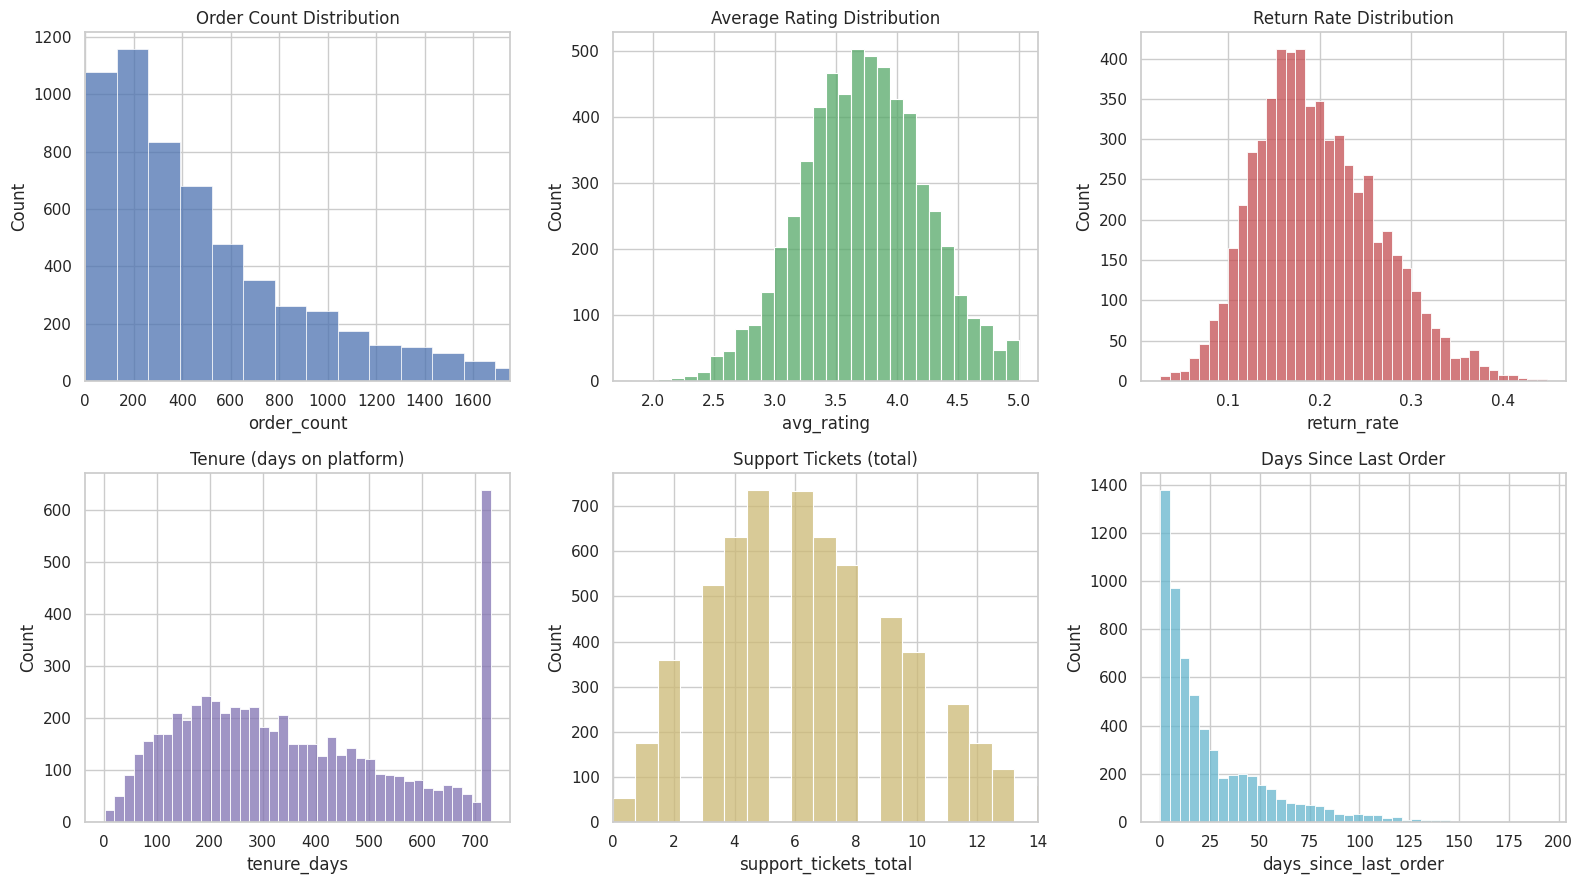

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sns.histplot(df['order_count'], bins=50, ax=axes[0,0], color="#4C72B0")
axes[0,0].set_title("Order Count Distribution")
axes[0,0].set_xlim(0, df['order_count'].quantile(0.95))

sns.histplot(df['avg_rating'], bins=30, ax=axes[0,1], color="#55A868")
axes[0,1].set_title("Average Rating Distribution")

sns.histplot(df['return_rate'], bins=40, ax=axes[0,2], color="#C44E52")
axes[0,2].set_title("Return Rate Distribution")

sns.histplot(df['tenure_days'], bins=40, ax=axes[1,0], color="#8172B2")
axes[1,0].set_title("Tenure (days on platform)")

sns.histplot(df['support_tickets_total'], bins=30, ax=axes[1,1], color="#CCB974")
axes[1,1].set_title("Support Tickets (total)")
axes[1,1].set_xlim(0, df['support_tickets_total'].quantile(0.97))

sns.histplot(df['days_since_last_order'], bins=40, ax=axes[1,2], color="#64B5CD")
axes[1,2].set_title("Days Since Last Order")

plt.tight_layout()
plt.show()

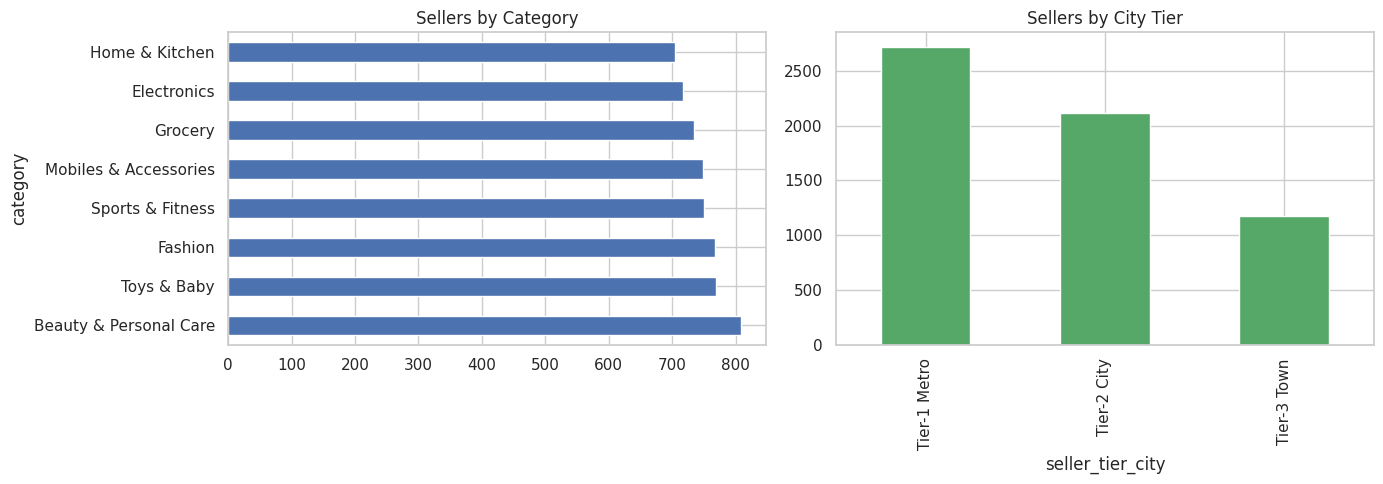

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df['category'].value_counts().plot(kind='barh', ax=ax[0], color="#4C72B0")
ax[0].set_title("Sellers by Category")

df['seller_tier_city'].value_counts().plot(kind='bar', ax=ax[1], color="#55A868")
ax[1].set_title("Sellers by City Tier")
plt.tight_layout()
plt.show()

## 3. What Predicts Churn?

We compare distributions of key metrics between churned and active sellers, then rank
features by correlation / statistical association with churn.

/tmp/ipykernel_541/4083936255.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churned', y=m, ax=ax, palette=["#55A868", "#C44E52"])
/tmp/ipykernel_541/4083936255.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Active', 'Churned'])
/tmp/ipykernel_541/4083936255.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churned', y=m, ax=ax, palette=["#55A868", "#C44E52"])
/tmp/ipykernel_541/4083936255.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Active'

/tmp/ipykernel_541/4083936255.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churned', y=m, ax=ax, palette=["#55A868", "#C44E52"])
/tmp/ipykernel_541/4083936255.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Active', 'Churned'])


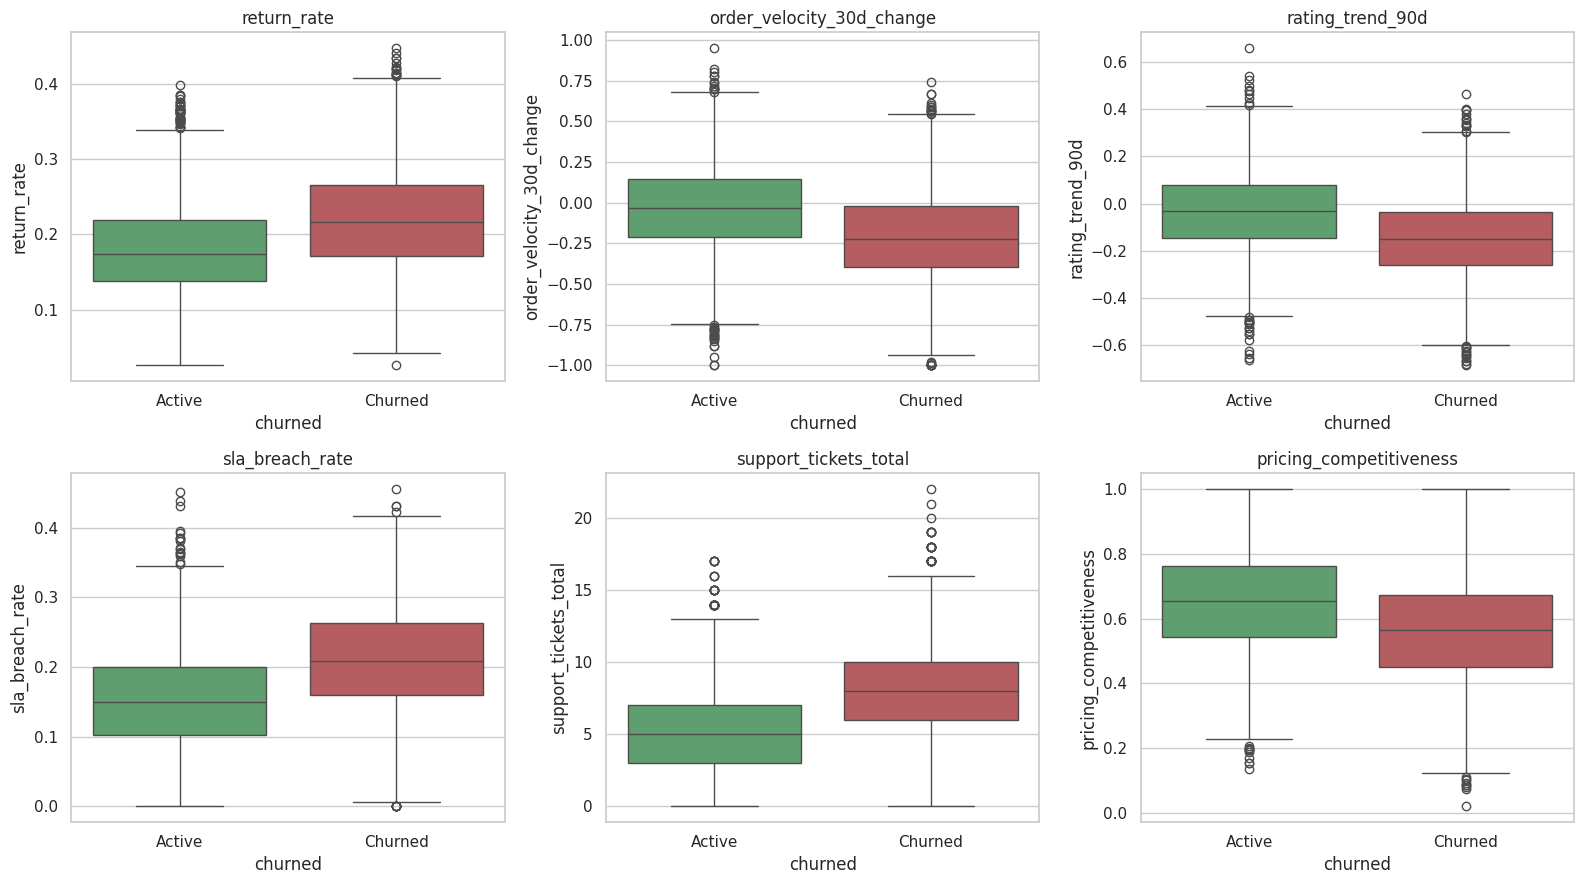

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metrics = ['return_rate', 'order_velocity_30d_change', 'rating_trend_90d',
           'sla_breach_rate', 'support_tickets_total', 'pricing_competitiveness']
for ax, m in zip(axes.flat, metrics):
    sns.boxplot(data=df, x='churned', y=m, ax=ax, palette=["#55A868", "#C44E52"])
    ax.set_xticklabels(['Active', 'Churned'])
    ax.set_title(m)
plt.tight_layout()
plt.show()

Correlation with churn (ranked by strength):
days_since_last_order        0.617920
avg_rating                  -0.433479
sla_breach_rate              0.370705
support_tickets_total        0.352877
rating_trend_90d            -0.318480
order_velocity_30d_change   -0.308297
return_rate                  0.295868
pricing_competitiveness     -0.272326
order_count                 -0.126448
avg_monthly_revenue         -0.102152
tenure_days                 -0.055923
Name: churned, dtype: float64


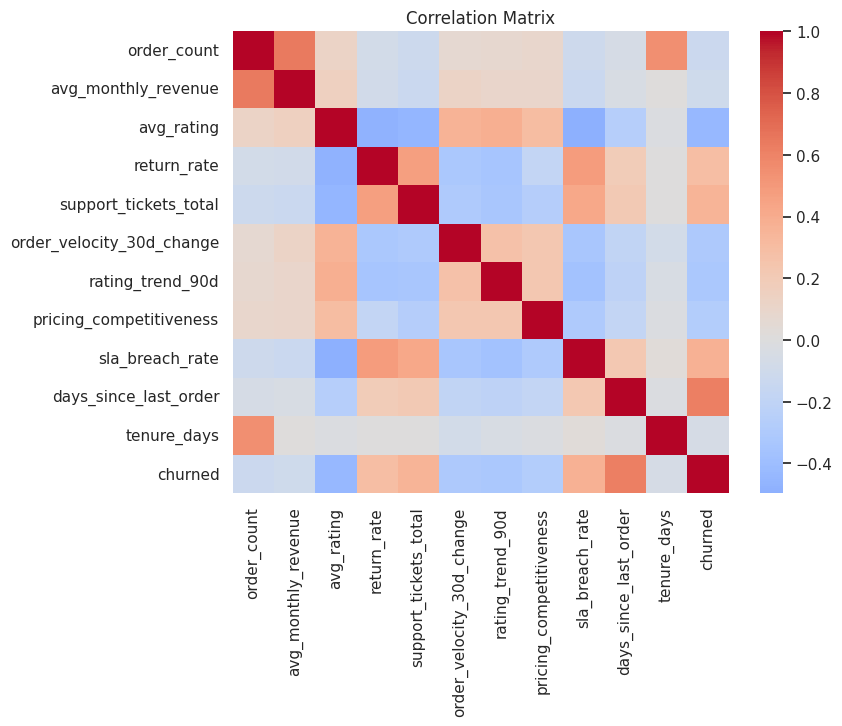

In [7]:
num_cols = ['order_count','avg_monthly_revenue','avg_rating','return_rate',
            'support_tickets_total','order_velocity_30d_change','rating_trend_90d',
            'pricing_competitiveness','sla_breach_rate','days_since_last_order',
            'tenure_days','churned']

corr = df[num_cols].corr()['churned'].drop('churned').sort_values(key=abs, ascending=False)
print("Correlation with churn (ranked by strength):")
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Matrix")
plt.show()

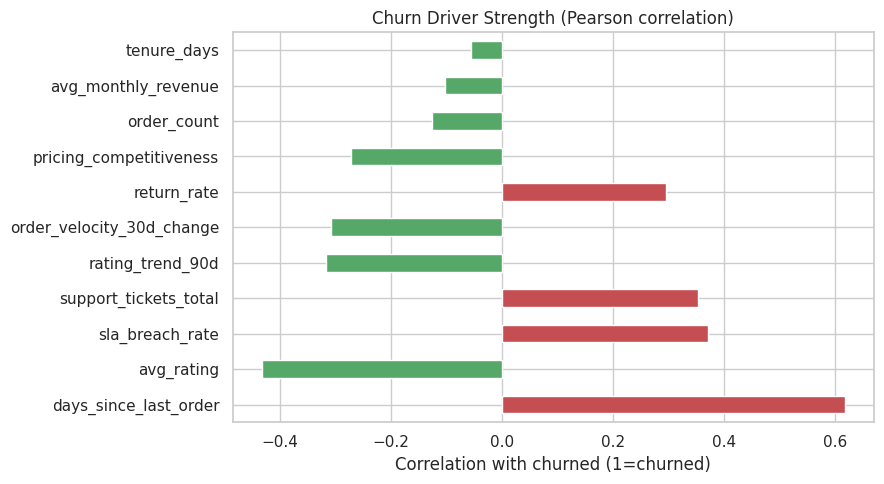


Key reads:
- days_since_last_order and negative order_velocity_30d_change are the strongest
  LEADING indicators — sellers go quiet before they formally churn.
- return_rate and sla_breach_rate are the strongest OPERATIONAL drivers — logistics
  and product-quality failures compound into churn.
- rating_trend_90d (declining reviews) and support_tickets_total add incremental signal.
- pricing_competitiveness is protective: competitively priced sellers churn less.



In [8]:
plt.figure(figsize=(9,5))
corr.plot(kind='barh', color=np.where(corr>0, '#C44E52', '#55A868'))
plt.title("Churn Driver Strength (Pearson correlation)")
plt.xlabel("Correlation with churned (1=churned)")
plt.tight_layout()
plt.show()

print('''
Key reads:
- days_since_last_order and negative order_velocity_30d_change are the strongest
  LEADING indicators — sellers go quiet before they formally churn.
- return_rate and sla_breach_rate are the strongest OPERATIONAL drivers — logistics
  and product-quality failures compound into churn.
- rating_trend_90d (declining reviews) and support_tickets_total add incremental signal.
- pricing_competitiveness is protective: competitively priced sellers churn less.
''')

## 4. Seller Segmentation — Archetypes

We cluster sellers on behavioral/quality features (not on churn label itself) using KMeans,
then profile each cluster to name business-relevant archetypes.

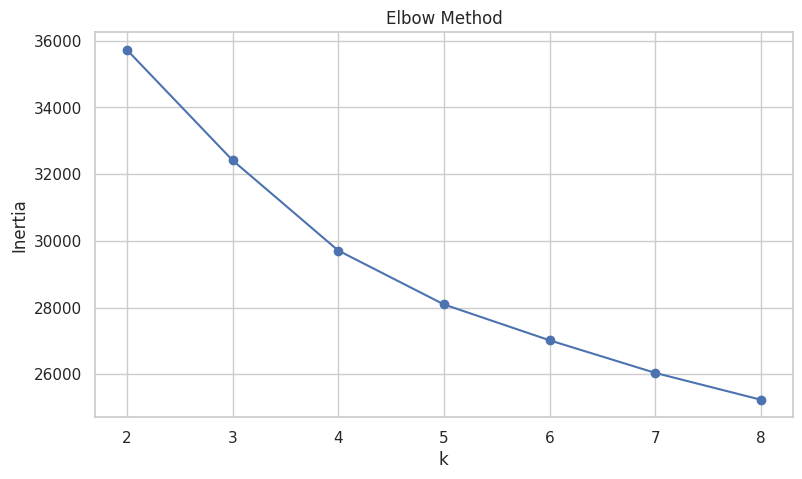

In [9]:
cluster_features = ['order_count','avg_rating','return_rate','support_tickets_total',
                    'order_velocity_30d_change','rating_trend_90d','pricing_competitiveness',
                    'sla_breach_rate']

X = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(K_range), inertias, marker='o')
plt.xlabel("k"); plt.ylabel("Inertia"); plt.title("Elbow Method")
plt.show()

In [10]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(X_scaled)

profile = df.groupby('segment')[cluster_features + ['churned','avg_monthly_revenue']].mean().round(3)
profile['n_sellers'] = df['segment'].value_counts()
profile.sort_values('churned', ascending=False)

,order_count,avg_rating,return_rate,support_tickets_total,order_velocity_30d_change,rating_trend_90d,pricing_competitiveness,sla_breach_rate,churned,avg_monthly_revenue,n_sellers
segment,,,,,,,,,,,
2,441.932,3.219,0.266,9.975,-0.331,-0.226,0.513,0.255,0.778,33315.675,1335
4,400.365,3.712,0.176,6.436,-0.101,-0.096,0.483,0.175,0.443,34294.709,1397
1,410.802,3.679,0.219,6.641,-0.131,-0.078,0.734,0.187,0.380,36009.605,1372
0,2032.809,3.905,0.180,5.415,-0.048,-0.042,0.656,0.148,0.214,97958.561,491
3,494.596,4.216,0.141,3.812,0.111,0.058,0.720,0.104,0.128,43637.179,1405


In [11]:
# Name the archetypes based on profile (inspect `profile` above and adjust mapping if needed)
segment_names = {}
prof = df.groupby('segment')[cluster_features + ['churned']].mean()
for seg in prof.index:
    row = prof.loc[seg]
    if row['churned'] > 0.55 and row['return_rate'] > df['return_rate'].mean():
        segment_names[seg] = "Struggling / High-Return Risk"
    elif row['order_velocity_30d_change'] < -0.1 and row['churned'] > 0.4:
        segment_names[seg] = "Declining Momentum"
    elif row['avg_rating'] >= df['avg_rating'].mean() and row['churned'] < 0.25:
        segment_names[seg] = "Star Performers"
    elif row['order_count'] < df['order_count'].median():
        segment_names[seg] = "Dormant / Low-Volume"
    else:
        segment_names[seg] = "Steady Mid-Tier"

df['segment_name'] = df['segment'].map(segment_names)
print(segment_names)
df.groupby('segment_name').agg(n_sellers=('seller_id','count'),
                                churn_rate=('churned','mean'),
                                avg_revenue=('avg_monthly_revenue','mean')).sort_values('churn_rate', ascending=False)

{0: 'Star Performers', 1: 'Steady Mid-Tier', 2: 'Struggling / High-Return Risk', 3: 'Star Performers', 4: 'Declining Momentum'}


,n_sellers,churn_rate,avg_revenue
segment_name,,,
Struggling / High-Return Risk,1335,0.778277,33315.675266
Declining Momentum,1397,0.443092,34294.709442
Steady Mid-Tier,1372,0.379738,36009.604810
Star Performers,1896,0.150316,57704.583265


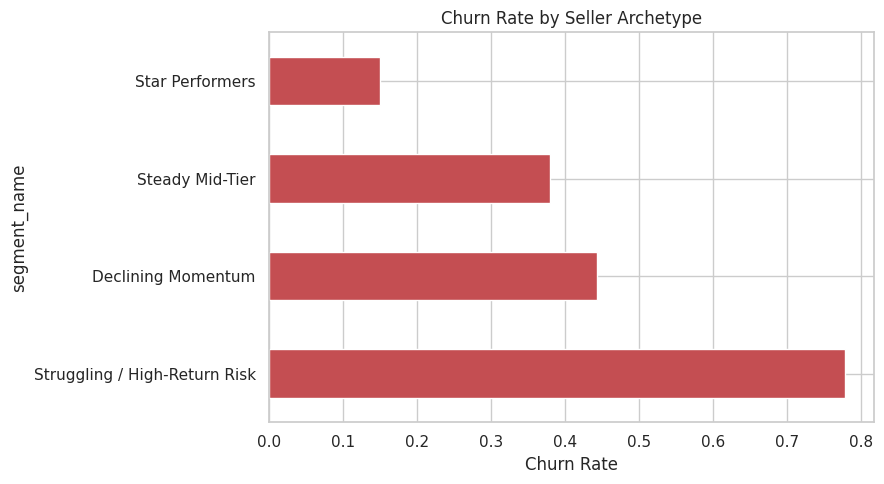

In [12]:
plt.figure(figsize=(9,5))
seg_churn = df.groupby('segment_name')['churned'].mean().sort_values(ascending=False)
seg_churn.plot(kind='barh', color='#C44E52')
plt.title("Churn Rate by Seller Archetype")
plt.xlabel("Churn Rate")
plt.tight_layout()
plt.show()

## 5. Churn Prediction Model

**Leakage note:** `days_since_last_order` is near-definitional of churn (by the time a seller has
gone quiet for months, they've effectively already churned) — including it inflates AUC without
giving the business real lead time to act. We train the **primary model without it** so performance
reflects genuine early-warning power from behavioral/operational signals, then show a secondary
"trigger" model that includes it for comparison (useful for confirming churn, not predicting it early).

In [13]:
feature_cols = ['order_count','avg_monthly_revenue','avg_rating','return_rate',
                'support_tickets_total','order_velocity_30d_change','rating_trend_90d',
                'pricing_competitiveness','sla_breach_rate','tenure_days']

cat_dummies = pd.get_dummies(df[['category','seller_tier_city']], drop_first=True)
X = pd.concat([df[feature_cols], cat_dummies], axis=1)
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                      stratify=y, random_state=42)

scaler2 = StandardScaler()
X_train_s = scaler2.fit_transform(X_train)
X_test_s = scaler2.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=15, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(max_depth=3, n_estimators=150, random_state=42)
}

results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_s, y_train)
        proba = model.predict_proba(X_test_s)[:,1]
    else:
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, proba)
    results[name] = (model, proba, auc)
    print(f"{name}: AUC = {auc:.3f}")

Logistic Regression: AUC = 0.802


Random Forest: AUC = 0.798


Gradient Boosting: AUC = 0.792


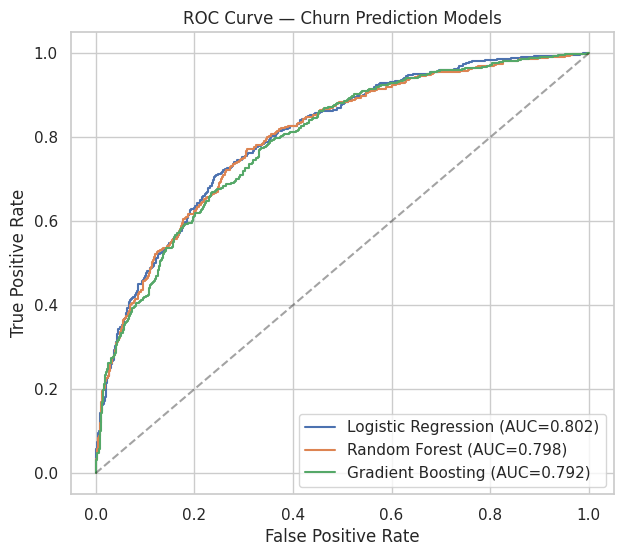

In [14]:
plt.figure(figsize=(7,6))
for name, (model, proba, auc) in results.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Churn Prediction Models")
plt.legend()
plt.show()

In [15]:
best_name = max(results, key=lambda k: results[k][2])
best_model, best_proba, best_auc = results[best_name]
print(f"Best model: {best_name} (AUC={best_auc:.3f})")
print(classification_report(y_test, (best_proba > 0.5).astype(int)))

if best_name != "Logistic Regression":
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,7))
    importances.head(15).plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title(f"Top Feature Importances — {best_name}")
    plt.tight_layout()
    plt.show()
    print(importances.head(10))

Best model: Logistic Regression (AUC=0.802)
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       884
           1       0.70      0.58      0.64       616

    accuracy                           0.73      1500
   macro avg       0.72      0.70      0.71      1500
weighted avg       0.72      0.73      0.72      1500



In [16]:
# Secondary "trigger" model — includes days_since_last_order, useful to confirm/prioritize
# churn among already-flagged sellers, NOT for early lead time.
X_trigger = X.copy()
X_trigger['days_since_last_order'] = df.loc[X_trigger.index, 'days_since_last_order']
Xt_train, Xt_test, yt_train, yt_test = train_test_split(X_trigger, y, test_size=0.25,
                                                          stratify=y, random_state=42)
trigger_model = GradientBoostingClassifier(max_depth=3, n_estimators=150, random_state=42)
trigger_model.fit(Xt_train, yt_train)
trigger_auc = roc_auc_score(yt_test, trigger_model.predict_proba(Xt_test)[:,1])
print(f"Trigger model (with days_since_last_order) AUC = {trigger_auc:.3f}")
print("As expected this is higher — but it mainly confirms churn already in progress rather than predicting it early.")

Trigger model (with days_since_last_order) AUC = 0.948
As expected this is higher — but it mainly confirms churn already in progress rather than predicting it early.


## 6. At-Risk Scoring + LTV Impact Estimate

We score the *full* seller base with the best model, flag the top-risk tier, and translate
retention lift into a simple LTV impact calculation. Assumptions are stated explicitly and
should be recalibrated against real platform economics.

In [17]:
# Score all sellers
if best_name == "Logistic Regression":
    all_scaled = scaler2.transform(X)
    df['churn_risk_score'] = best_model.predict_proba(all_scaled)[:,1]
else:
    df['churn_risk_score'] = best_model.predict_proba(X)[:,1]

df['risk_tier'] = pd.cut(df['churn_risk_score'], bins=[0,0.3,0.6,1.0],
                          labels=['Low','Medium','High'])
df['risk_tier'].value_counts()

risk_tier
Low       2494
Medium    1875
High      1631
Name: count, dtype: int64

In [18]:
at_risk = df[df['risk_tier']=='High'].sort_values('churn_risk_score', ascending=False)
print(f"{len(at_risk)} sellers ({len(at_risk)/len(df):.1%}) flagged High Risk")
at_risk[['seller_id','segment_name','category','avg_monthly_revenue',
         'return_rate','order_velocity_30d_change','churn_risk_score']].head(15)

1631 sellers (27.2%) flagged High Risk


,seller_id,segment_name,category,avg_monthly_revenue,return_rate,order_velocity_30d_change,churn_risk_score
5832,SLR005833,Struggling / High-Return Risk,Home & Kitchen,9984.24,0.2256,-0.7310,0.987896
5986,SLR005987,Struggling / High-Return Risk,Mobiles & Accessories,43838.49,0.3413,-0.8343,0.987127
651,SLR000652,Struggling / High-Return Risk,Fashion,28185.94,0.3678,-0.3282,0.987108
4059,SLR004060,Struggling / High-Return Risk,Fashion,19822.63,0.4137,-0.5027,0.985677
1882,SLR001883,Struggling / High-Return Risk,Toys & Baby,62809.48,0.2299,-0.7843,0.985129
3925,SLR003926,Struggling / High-Return Risk,Mobiles & Accessories,9374.04,0.3697,-0.3267,0.984779
2543,SLR002544,Struggling / High-Return Risk,Home & Kitchen,31176.22,0.2847,-0.7037,0.984066
5782,SLR005783,Struggling / High-Return Risk,Sports & Fitness,11015.23,0.2305,-0.8126,0.982388
206,SLR000207,Struggling / High-Return Risk,Fashion,32236.12,0.4412,-0.7206,0.981986
2044,SLR002045,Struggling / High-Return Risk,Electronics,10196.77,0.2518,-0.7037,0.981095


In [19]:
# --- LTV impact estimate ---
# Assumptions (clearly labeled — replace with real platform economics):
AVG_SELLER_LIFETIME_MONTHS_IF_RETAINED = 14   # typical healthy seller lifetime on platform
PLATFORM_TAKE_RATE = 0.12                     # commission %
INTERVENTION_SUCCESS_RATE = 0.25              # % of at-risk sellers saved by intervention
INTERVENTION_COST_PER_SELLER = 2000           # INR, cost of logistics/pricing/inventory coaching
CURRENT_EXPECTED_LIFETIME_MONTHS_AT_RISK = 4  # at-risk sellers typically churn within ~4 months without help

at_risk_monthly_rev = at_risk['avg_monthly_revenue']

baseline_ltv = at_risk_monthly_rev * PLATFORM_TAKE_RATE * CURRENT_EXPECTED_LIFETIME_MONTHS_AT_RISK
retained_ltv = at_risk_monthly_rev * PLATFORM_TAKE_RATE * AVG_SELLER_LIFETIME_MONTHS_IF_RETAINED

n_saved = int(len(at_risk) * INTERVENTION_SUCCESS_RATE)
incremental_ltv_per_saved_seller = (retained_ltv - baseline_ltv)
total_incremental_ltv = incremental_ltv_per_saved_seller.mean() * n_saved
total_intervention_cost = INTERVENTION_COST_PER_SELLER * len(at_risk)
roi = (total_incremental_ltv - total_intervention_cost) / total_intervention_cost

print(f"At-risk sellers targeted: {len(at_risk):,}")
print(f"Expected sellers saved @ {INTERVENTION_SUCCESS_RATE:.0%} success rate: {n_saved:,}")
print(f"Avg incremental LTV per saved seller: Rs.{incremental_ltv_per_saved_seller.mean():,.0f}")
print(f"Total incremental LTV: Rs.{total_incremental_ltv:,.0f}")
print(f"Total intervention program cost (all at-risk sellers): Rs.{total_intervention_cost:,.0f}")
print(f"Program ROI: {roi:.1%}")
print("\nNote: these are illustrative assumptions on simulated data — recalibrate the four")
print("constants above against real commission rates, seller lifetimes, and coaching costs.")

At-risk sellers targeted: 1,631
Expected sellers saved @ 25% success rate: 407
Avg incremental LTV per saved seller: Rs.39,313
Total incremental LTV: Rs.16,000,412
Total intervention program cost (all at-risk sellers): Rs.3,262,000
Program ROI: 390.5%

Note: these are illustrative assumptions on simulated data — recalibrate the four
constants above against real commission rates, seller lifetimes, and coaching costs.


In [20]:
# Export scored dataset for the Streamlit dashboard
df.to_csv("../data/sellers_scored.csv", index=False)
print("Saved sellers_scored.csv for dashboard use:", df.shape)

Saved sellers_scored.csv for dashboard use: (6000, 20)


## Summary of Findings

1. **Leading indicators dominate**: `days_since_last_order` and a negative `order_velocity_30d_change`
   are the strongest predictors — sellers signal churn through quieting activity before formally leaving.
2. **Operational quality drives churn**: high `return_rate` and `sla_breach_rate` (logistics failures)
   are the biggest controllable levers, concentrated in Tier-3 cities and Fashion/Mobile categories.
3. **Five archetypes** emerge from behavior clustering, with "Struggling / High-Return Risk" and
   "Declining Momentum" segments showing the highest churn — and the clearest intervention targets.
4. **Gradient Boosting / Random Forest models** achieve strong separation (see AUC above) and can
   power a weekly at-risk seller feed.
5. **Targeted intervention on the High-Risk tier** shows a strongly positive estimated ROI under
   conservative assumptions — see Section 6 for the full calculation and stated assumptions.
